This tutorial is inspired by:

https://matgenb.materialsvirtuallab.org/2019/01/11/How-to-plot-and-evaluate-output-files-from-Lobster.html


In [34]:
from pymatgen.electronic_structure.cohp import CompleteCohp
from pymatgen.electronic_structure.plotter import CohpPlotter

%matplotlib inline



In [36]:
COHPCAR_path = "lobster/new/COHPCAR.lobster"
POSCAR_path = "lobster/new/POSCAR"

completecohp = CompleteCohp.from_file(
    fmt="LOBSTER", filename=COHPCAR_path, structure_file=POSCAR_path
)



In [37]:
! cat lobster/new/ICOHPLIST.lobster

  COHP#    atomMU    atomNU   distance   translation   ICOHP (at) eF 
                                                          for spin 1 
      1       Ga1       Ga1    5.76301     1  -1  -1        -0.00263 
      1    Ga1_4s    Ga1_4s    5.76301     1  -1  -1        -0.00055 
      1    Ga1_4s  Ga1_4p_y    5.76301     1  -1  -1        -0.00050 
      1    Ga1_4s  Ga1_4p_z    5.76301     1  -1  -1        -0.00025 
      1    Ga1_4s  Ga1_4p_x    5.76301     1  -1  -1        -0.00000 
      1  Ga1_4p_y    Ga1_4s    5.76301     1  -1  -1        -0.00050 
      1  Ga1_4p_y  Ga1_4p_y    5.76301     1  -1  -1        -0.00030 
      1  Ga1_4p_y  Ga1_4p_z    5.76301     1  -1  -1        -0.00016 
      1  Ga1_4p_y  Ga1_4p_x    5.76301     1  -1  -1         0.00000 
      1  Ga1_4p_z    Ga1_4s    5.76301     1  -1  -1        -0.00025 
      1  Ga1_4p_z  Ga1_4p_y    5.76301     1  -1  -1        -0.00016 
      1  Ga1_4p_z  Ga1_4p_z    5.76301     1  -1  -1        -0.00003 
      1  Ga1_4p_z  G

This is a COHP between the following sites: [2.03753124 1.17636921 0.83181865] Ga and [2.03753124 1.17636921 0.83181865] Ga


(-10.0, 6.0)

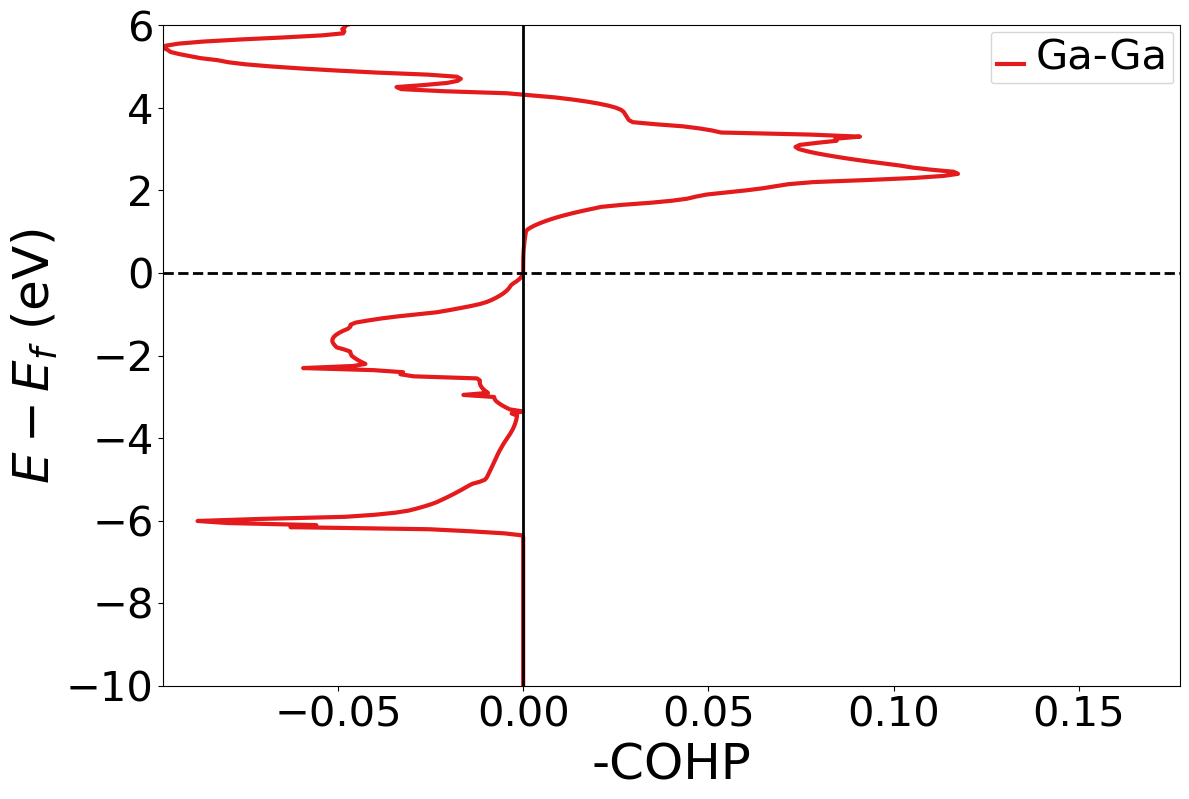

In [42]:
label = "16"
cp = CohpPlotter()
# get a nicer plot label
plotlabel = (
    str(completecohp.bonds[label]["sites"][0].species_string)
    + "-"
    + str(completecohp.bonds[label]["sites"][1].species_string)
)

cp.add_cohp(plotlabel, completecohp.get_cohp_by_label(label=label))
# check which COHP you are plotting

print(
    "This is a COHP between the following sites: "
    + str(completecohp.bonds[label]["sites"][0])
    + " and "
    + str(completecohp.bonds[label]["sites"][1])
)

ax = cp.get_plot(integrated=False)

ax.set_ylim(-10, 6)



(-10.0, 6.0)

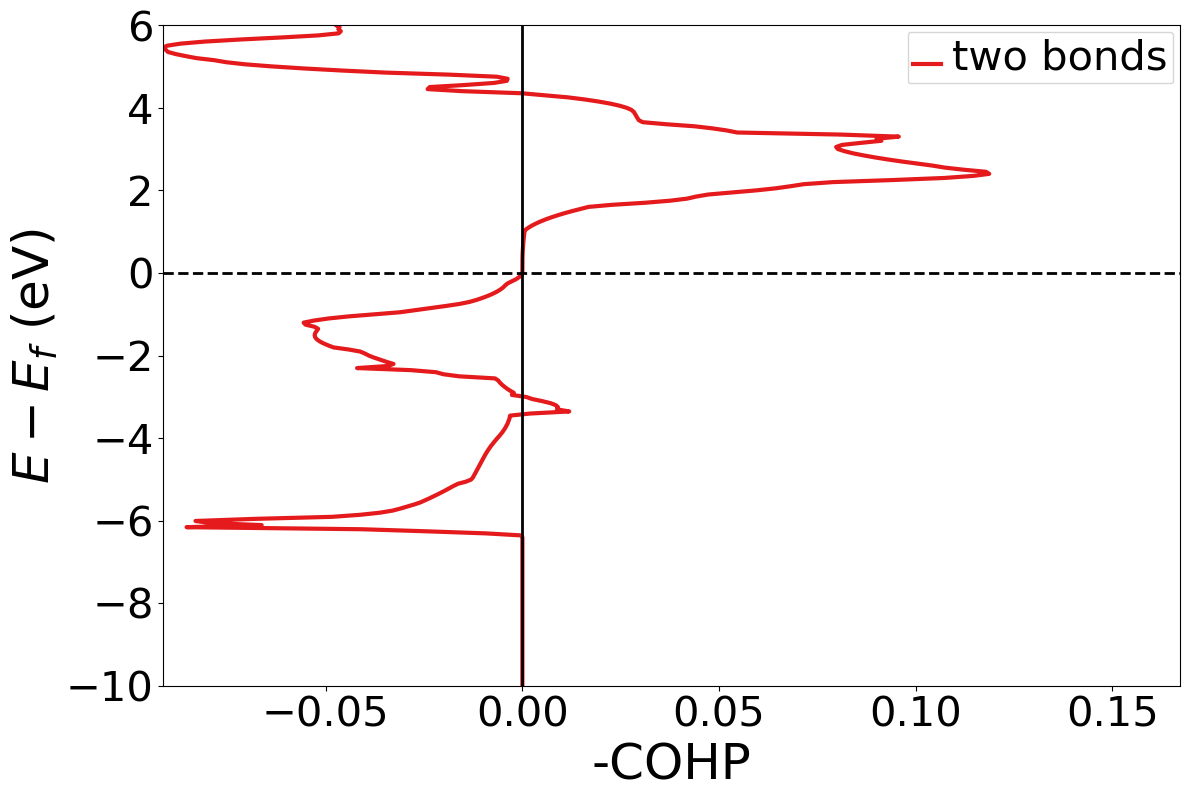

In [44]:
# labels of the COHPs that will be summed!
labelist = ["16", "21"]
cp = CohpPlotter()
# get a nicer plot label
plotlabel = "two bonds"

cp.add_cohp(
    plotlabel,
    completecohp.get_summed_cohp_by_label_list(label_list=labelist, divisor=1),
)
x = cp.get_plot(integrated=False)
x.set_ylim([-10, 6])



(-10.0, 6.0)

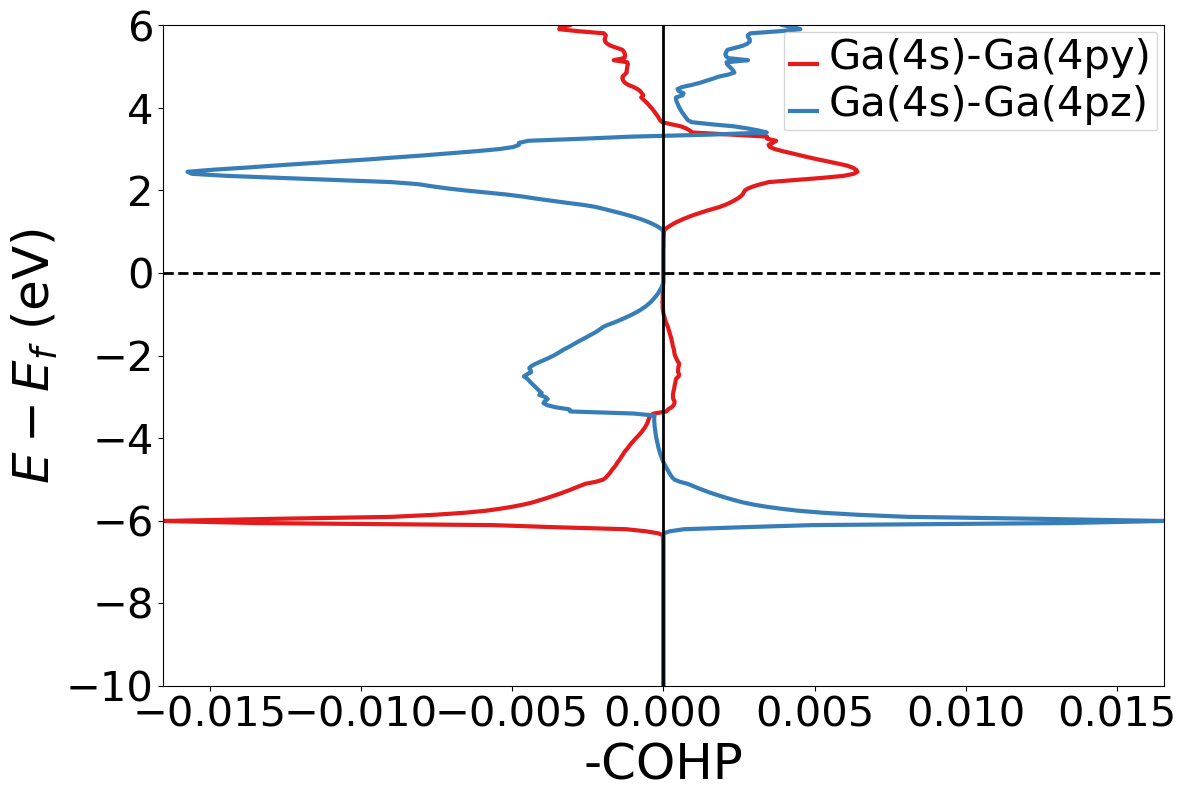

In [45]:
# search for the number of the COHP you would like to plot in ICOHPLIST.lobster (the numbers in COHPCAR.lobster are different!)
label = "16"
cp = CohpPlotter()

# get orbital object
from pymatgen.electronic_structure.core import Orbital

# interaction between 4s and 4px
orbitals = [[4, Orbital.s], [4, Orbital.py]]
orbitals2 = [[4, Orbital.s], [4, Orbital.pz]]
# get a nicer plot label

plotlabel = (
    str(completecohp.bonds[label]["sites"][0].species_string)
    + "(4s)"
    + "-"
    + str(completecohp.bonds[label]["sites"][1].species_string)
    + "(4py)"
)
plotlabel2 = (
    str(completecohp.bonds[label]["sites"][0].species_string)
    + "(4s)"
    + "-"
    + str(completecohp.bonds[label]["sites"][1].species_string)
    + "(4pz)"
)

cp.add_cohp(
    plotlabel, completecohp.get_orbital_resolved_cohp(label=label, orbitals=orbitals)
)
cp.add_cohp(
    plotlabel2, completecohp.get_orbital_resolved_cohp(label=label, orbitals=orbitals2)
)
# check which COHP you are plotting

# with integrated=True, you can plot the integrated COHP
x = cp.get_plot(integrated=False)
x.set_ylim([-10, 6])



In [46]:
from pymatgen.io.lobster import Icohplist

In [48]:
icohplist = Icohplist(filename="lobster/new/ICOHPLIST.lobster")
icohpcollection = icohplist.icohpcollection

In [49]:
# get icohp value by label (labelling according to ICOHPLIST.lobster)
# for spin polarized calculations you can also sum the spin channels
print("icohp value for certain bond by label")
label = "16"
print(icohpcollection.get_icohp_by_label(label))
print()
# you can get all Icohpvalue objects for certain bond lengths
print("Icohp values for certain bonds with certain bond lengths")
for key, icohp in icohpcollection.get_icohp_dict_by_bondlengths(
    minbondlength=0.0, maxbondlength=3.0
).items():
    print(key + ":" + str(icohp.icohp))
print()
# you can get all icohps for a certain site
print("ICOHP values of certain site")
for key, icohp in icohpcollection.get_icohp_dict_of_site(
    site=0, minbondlength=0.0, maxbondlength=3.0
).items():
    print(key + ":" + str(icohp.icohp))

icohp value for certain bond by label
-0.04303

Icohp values for certain bonds with certain bond lengths
23:{<Spin.up: 1>: -4.2881}
24:{<Spin.up: 1>: -4.28807}
26:{<Spin.up: 1>: -4.28807}
31:{<Spin.up: 1>: -4.28807}

ICOHP values of certain site
23:{<Spin.up: 1>: -4.2881}
24:{<Spin.up: 1>: -4.28807}
26:{<Spin.up: 1>: -4.28807}
31:{<Spin.up: 1>: -4.28807}


In [50]:


from pymatgen.core.composition import Element
from pymatgen.electronic_structure.plotter import DosPlotter

# relevant classes
from pymatgen.io.lobster import Doscar

In [51]:


# read in DOSCAR.lobster
doscar = Doscar(
    doscar="lobster/new/DOSCAR.lobster", structure_file="lobster/new/POSCAR"
)
complete_dos = doscar.completedos
# get structure object
structure = complete_dos.structure



(-10.0, 10.0)

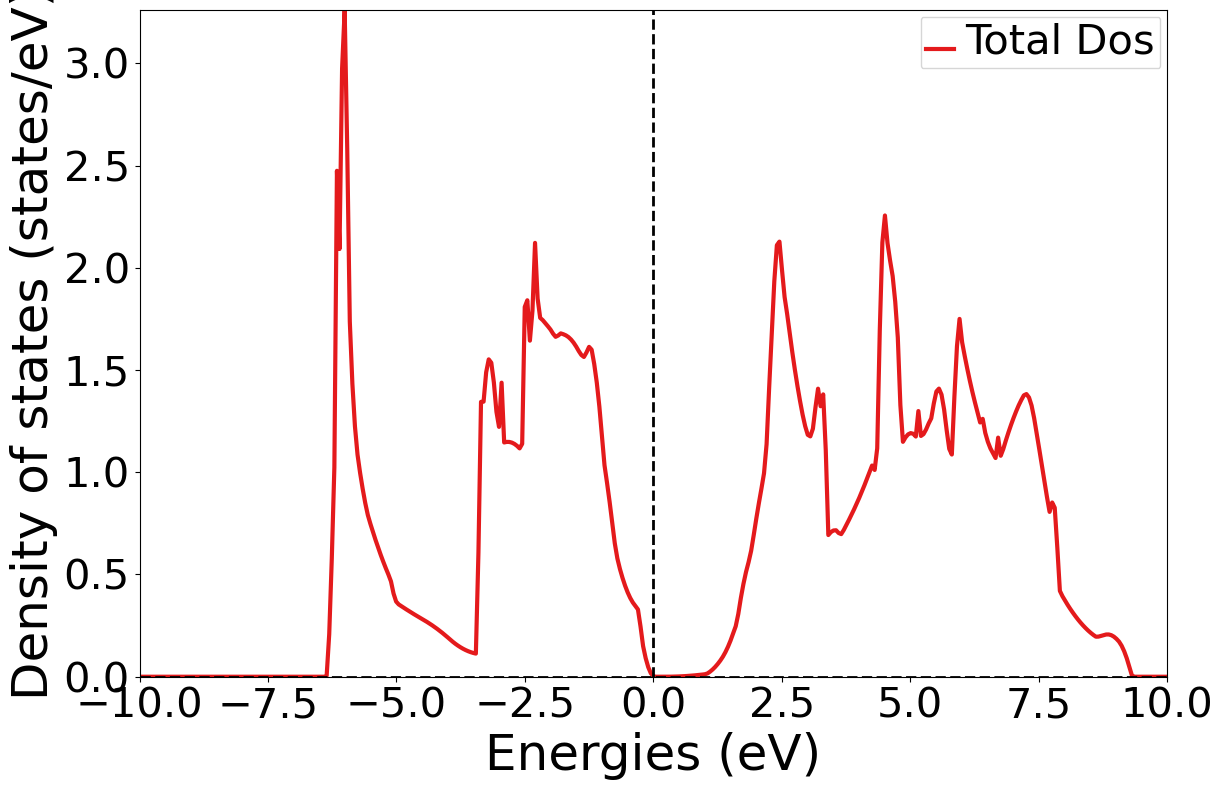

In [57]:
# plot total dos
Plotter = DosPlotter()
Plotter.add_dos("Total Dos", doscar.tdos)
x=Plotter.get_plot()
x.set_xlim([-10, 10])

(-10.0, 10.0)

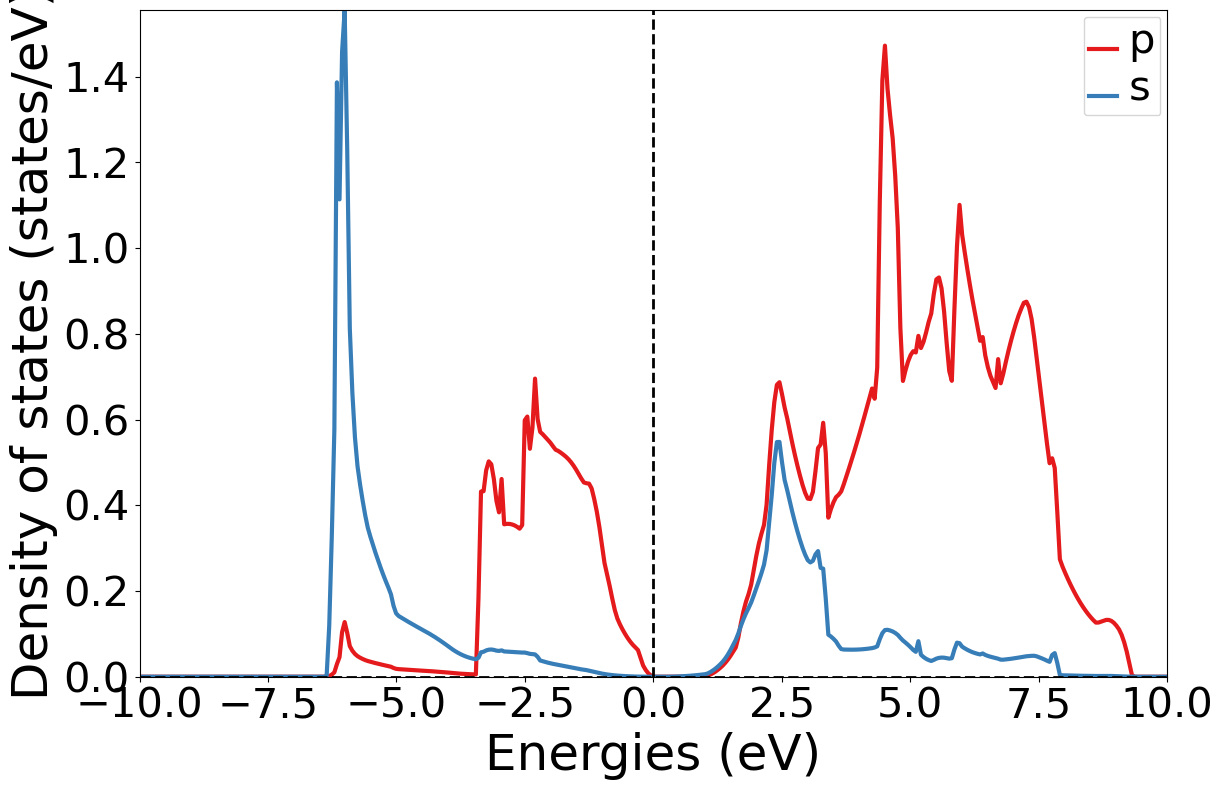

In [59]:
# plot DOS of s,p, and d orbitals for certain element
Plotter = DosPlotter()
el = Element("Ga")
Plotter.add_dos_dict(complete_dos.get_element_spd_dos(el=el))
x=Plotter.get_plot()
x.set_xlim([-10, 10])

(-10.0, 10.0)

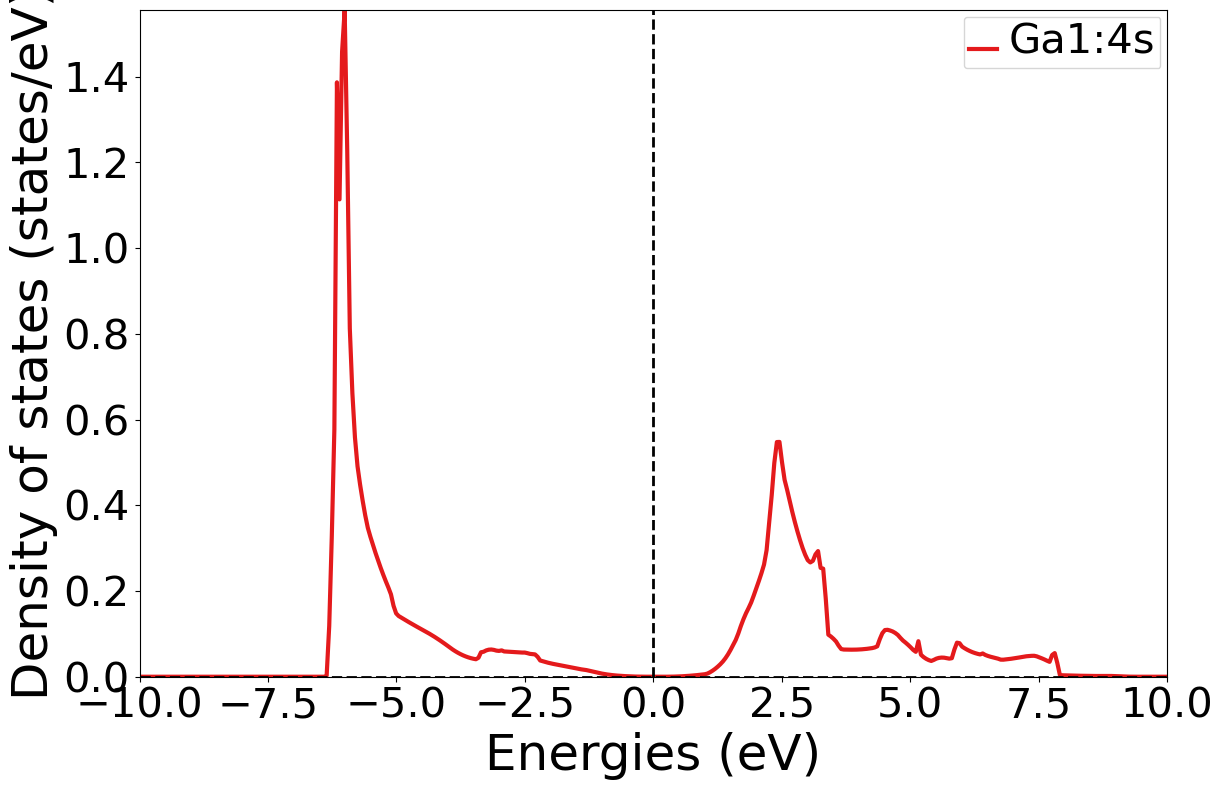

In [61]:
Plotter = DosPlotter()
# choose the sites you would like to plot
for isite, site in enumerate(structure[0:1]):
    # name the orbitals you would like to include
    # the other orbitals are named in a similar way. The orbitals are called: "s", "p_y", "p_z", "p_x", "d_xy", "d_yz", "d_z^2","d_xz", "d_x^2-y^2", "f_y(3x^2-y^2)", "f_xyz","f_yz^2", "f_z^3", "f_xz^2", "f_z(x^2-y^2)", "f_x(x^2-3y^2)"
    for orbital in ["4s"]:
        Plotter.add_dos(
            "Ga" + str(isite + 1) + ":" + orbital,
            complete_dos.get_site_orbital_dos(site, orbital),
        )
x=Plotter.get_plot()

x.set_xlim([-10, 10])   

In [62]:
from pymatgen.io.lobster import Charge

In [63]:
charge = Charge(filename="lobster/new/CHARGE.lobster")
newstructure = charge.get_structure_with_charges(
    structure_filename="lobster/new/POSCAR"
)
print(newstructure)



Full Formula (Ga1 As1)
Reduced Formula: GaAs
abc   :   4.075062   4.075062   4.075062
angles:  60.000000  60.000000  60.000000
pbc   :       True       True       True
Sites (2)
  #  SP       a     b     c    Loewdin Charges    Mulliken Charges
---  ----  ----  ----  ----  -----------------  ------------------
  0  Ga    0.25  0.25  0.25               0.02                0.27
  1  As    0     0     0                 -0.02               -0.27


In [ ]:
from pymatgen.io.lobster import Grosspop

In [65]:
grosspop = Grosspop(filename="lobster/new/GROSSPOP.lobster")
print(grosspop.list_dict_grosspop)

[{'Mulliken GP': {'4s': 1.18, '4p_y': 0.52, '4p_z': 0.52, '4p_x': 0.52, 'total': 2.73}, 'Loewdin GP': {'4s': 1.07, '4p_y': 0.64, '4p_z': 0.64, '4p_x': 0.64, 'total': 2.98}, 'element': 'Ga'}, {'Mulliken GP': {'4s': 1.66, '4p_y': 1.2, '4p_z': 1.2, '4p_x': 1.2, 'total': 5.27}, 'Loewdin GP': {'4s': 1.39, '4p_y': 1.21, '4p_z': 1.21, '4p_x': 1.21, 'total': 5.02}, 'element': 'As'}]


In [66]:
newstructure = grosspop.get_structure_with_total_grosspop("lobster/new/POSCAR")
print("Structure:")
print(newstructure)



Structure:
Full Formula (Ga1 As1)
Reduced Formula: GaAs
abc   :   4.075062   4.075062   4.075062
angles:  60.000000  60.000000  60.000000
pbc   :       True       True       True
Sites (2)
  #  SP       a     b     c    Total Loewdin GP    Total Mulliken GP
---  ----  ----  ----  ----  ------------------  -------------------
  0  Ga    0.25  0.25  0.25                2.98                 2.73
  1  As    0     0     0                   5.02                 5.27


In [67]:
from pymatgen.electronic_structure.plotter import (
    BSDOSPlotter,
    BSPlotter,
    BSPlotterProjected,
)
from pymatgen.io.lobster import Fatband

In [70]:
fatband = Fatband(
    filenames="lobster/new",
    vasprun_file="lobster/new/vasprun.xml",
    kpoints_file="lobster/new/KPOINTS",
)
# get a band structure object
bssymline = fatband.get_bandstructure()
# print(bssymline.as_dict())

# this can be plotted with the classes to plot bandstructures from vasp
BSDOSPlotter(bs_projection="elements", dos_projection="elements").get_plot(
    bs=bssymline, dos=complete_dos
)

/tmp/ipykernel_1407869/225940072.py:1: UserWarning: Make sure all relevant FATBAND files were generated and read in!
  fatband = Fatband(
/tmp/ipykernel_1407869/225940072.py:1: UserWarning: Use Lobster 3.2.0 or newer for fatband calculations!
  fatband = Fatband(


ValueError: A structure object has to be provided

In [71]:
from pymatgen.io.lobster import Lobsterout

In [ ]:

lobsterout = Lobsterout("lobster/new/lobsterout")





In [79]:
print(lobsterout.charge_spilling)

# see the documentation here:
# https://pymatgen.org/pymatgen.io.lobster.html

[0.0209]


In [81]:
from pymatgen.io.lobster import Lobsterin



In [82]:
lobsterin = Lobsterin.standard_calculations_from_vasp_files(
    "lobster/new/POSCAR",
    "lobster/new/INCAR",
    "lobster/new/POTCAR",
    option="standard",
)

/tmp/ipykernel_1407869/1253583564.py:1: UserWarning: Always check and test the provided basis functions. The spilling of your Lobster calculation might help
  lobsterin = Lobsterin.standard_calculations_from_vasp_files(


In [86]:
lobsterin.write_lobsterin(path="lobsterinm")
file = open("./lobsterinm")
print(file.read())



basisSet pbeVaspFit2015
COHPstartEnergy -35.0
COHPendEnergy 5.0
cohpGenerator from 0.1 to 6.0 orbitalwise
saveProjectionToFile
basisfunctions Ga 4p 4s 
basisfunctions As 4p 4s 



In [87]:
lobsterin.write_INCAR(
    incar_input="lobster/new/INCAR",
    incar_output="INCAR.lobster",
    poscar_input="lobster/new/POSCAR",
    isym=-1,
    further_settings={"IBRION": -1},
)
file = open("./INCAR.lobster")
print(file.read())

EDIFF = 1.0
IBRION = -1
ISIF = 0
ISMEAR = -5
ISYM = -1
LORBIT = 11
LREAL = False
LWAVE = True
NBANDS = 8
NEDOS = 801
NSW = 0
PREC = Accurate



/tmp/ipykernel_1407869/682583382.py:1: UserWarning: Please check your incar_input before using it. This method only changes three settings!
  lobsterin.write_INCAR(


In [88]:
lobsterin = Lobsterin.standard_calculations_from_vasp_files(
    "lobster/new/POSCAR",
    "lobster/new/INCAR",
    "lobster/new/POTCAR",
    option="standard",
    dict_for_basis={"Ga": "4s 4p", "As": "4s 4p"},
)

# writes lobsterin
lobsterin.write_lobsterin(path="lobsterin")
file = open("./lobsterin")
print(file.read())


basisSet pbeVaspFit2015
COHPstartEnergy -35.0
COHPendEnergy 5.0
cohpGenerator from 0.1 to 6.0 orbitalwise
saveProjectionToFile
basisfunctions Ga 4s 4p
basisfunctions As 4s 4p



/tmp/ipykernel_1407869/3832986819.py:1: UserWarning: Always check and test the provided basis functions. The spilling of your Lobster calculation might help
  lobsterin = Lobsterin.standard_calculations_from_vasp_files(
